In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/sharvarikargutkar/Heart-Disease-Prediction-using-Machine-Learning/refs/heads/main/heart.csv"

Step 1 — Load, Explore & Preprocess

In [3]:
df =pd.read_csv(url)
df.head(10)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(302, 14)

In [10]:
X=df.drop('target',axis=1)
Y=df['target']

In [11]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [12]:
df.shape

(302, 14)

In [13]:
X_train.shape

(241, 13)

In [14]:
X_test.shape

(61, 13)

In [15]:
Y_train.shape

(241,)

In [16]:
Y_test.shape

(61,)

Step 1 — Load, Explore & Preprocess (Explanation)

1. After loading the dataset, we checked that the data contains **1025** rows and **14** columns.

2. No null values were found, making the data ready for analysis.

3. The data contained every column in numerical format, eliminating the process of encoding categorical values.

4. The data contained around **723** duplicate records, which were removed to have unique data for training the model, leaving **302** rows and **14** columns.

5. The data was then divided into a ratio of **80:20**, where **80%** of the data is being used for training, that is **241** rows of data, and **20%** is used to check whether the model is accurate or not, that is **61** values.


Step 2 — Feature Engineering

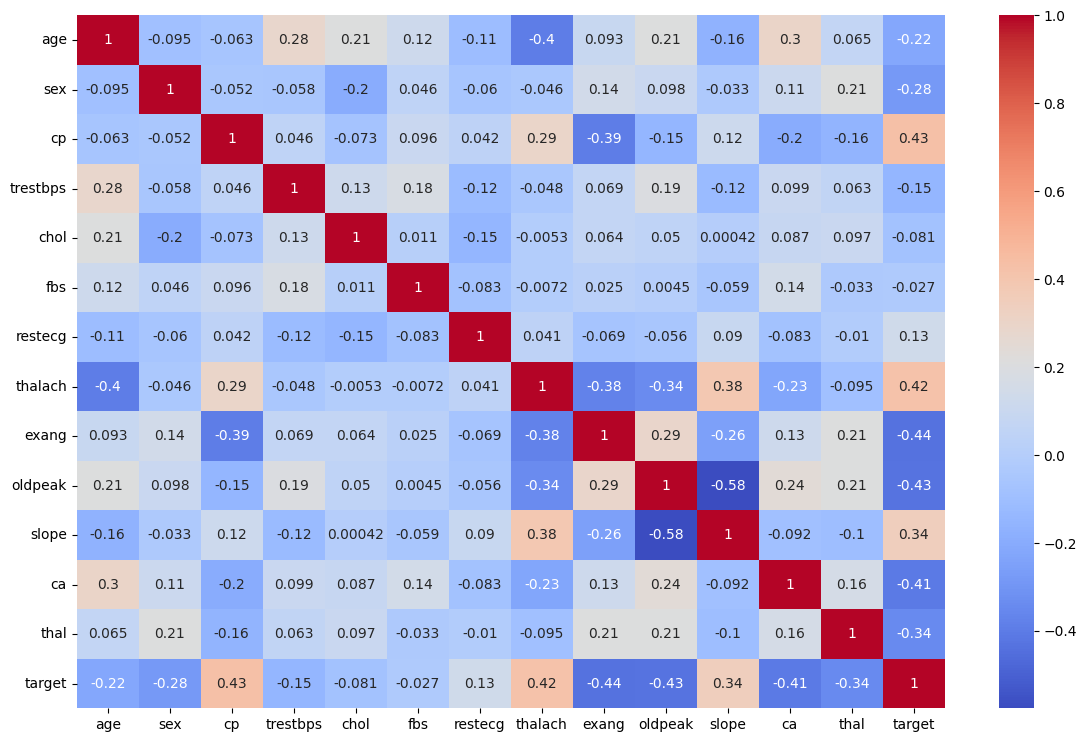

In [17]:
corr=df.corr()
plt.figure(figsize=(14,9))
sns.heatmap(corr,annot=True , cmap="coolwarm")

plt.show()

Summary

Based on the correlation heatmap:

1. **fbs (-0.03)** and **chol (-0.08)** showed extremely weak correlation with the target and were identified as the least important features.

2. **age (-0.22), sex (-0.28), trestbps (-0.15), and restecg (0.13)** showed weak correlation with the target but were not weak enough to be dropped.

3. Features such as **cp (0.43), thalach (0.42), exang (-0.44), oldpeak (-0.43), ca (-0.41), slope (0.34),** and **thal (-0.34)** showed moderate correlation and were considered the most influential features for predicting heart disease.

4. Based on the correlation analysis, fbs and chol were identified as the least important features and are potential candidates for removal due to their extremely weak correlation with the target variable.


In [18]:
df.shape

(302, 14)

In [19]:
df=df.drop(['fbs','chol'],axis=1)
df.shape

(302, 12)

Step 2:- Summary

Based on the above summary, the weakest features, fbs and chol, were dropped as they were significantly unlikely to contribute to the prediction.

The remaining features showed relatively stronger relationships with the target and were retained in the model. The reduction in the number of columns can be verified using the .shape function, which shows that the dataset now contains 12 features instead of 14.

 Step 3 — Train 3 Different Models

In [20]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train,Y_train)
lr_pred = lr.predict(X_test)

In [21]:
knn= KNeighborsClassifier()
knn.fit(X_train,Y_train)
knn_pred = knn.predict(X_test)

In [22]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train,Y_train)
dtc_pred = dtc.predict(X_test)

In [23]:
rfc = RandomForestClassifier()
rfc.fit(X_train,Y_train)
rfc_pred = rfc.predict(X_test)

In [24]:
nb = GaussianNB()
nb.fit(X_train,Y_train)
nb_pred = nb.predict(X_test)

 Step 3 — Train 3 Different Models(Explaination)

 Five classification models were trained on the processed heart disease dataset:
 1. Logistic Regression
 2. KNN (K Nearest Neighbor)
 3. Decision Tree
 4. Random Forest
 5. Naive Bayes

 The training data consisted of 241 records, which were provided to the models using the .fit() function, while predictions were generated on the 61 test records using the .predict() function.

 These models will be evaluated and compared in the next step using classification metrics.

Step 4 — Evaluation & Comparison

In [25]:
print("Logistic Regression Metrics : ")
print("Accuracy :", accuracy_score(Y_test, lr_pred))
print("Precision:", precision_score(Y_test, lr_pred))
print("Recall   :", recall_score(Y_test, lr_pred))
print("F1 Score :", f1_score(Y_test, lr_pred))

Logistic Regression Metrics : 
Accuracy : 0.8524590163934426
Precision: 0.8648648648648649
Recall   : 0.8888888888888888
F1 Score : 0.8767123287671232


In [26]:
print("KNN Metrics : ")
print("Accuracy :", accuracy_score(Y_test,knn_pred))
print("Precision:", precision_score(Y_test,knn_pred))
print("Recall   :", recall_score(Y_test,knn_pred))
print("F1 Score :", f1_score(Y_test,knn_pred))

KNN Metrics : 
Accuracy : 0.5901639344262295
Precision: 0.6410256410256411
Recall   : 0.6944444444444444
F1 Score : 0.6666666666666666


In [27]:
print("Decision Tree Metrics : ")
print("Accuracy :", accuracy_score(Y_test,dtc_pred))
print("Precision:", precision_score(Y_test,dtc_pred))
print("Recall   :", recall_score(Y_test,dtc_pred))
print("F1 Score :", f1_score(Y_test,dtc_pred))

Decision Tree Metrics : 
Accuracy : 0.7868852459016393
Precision: 0.8108108108108109
Recall   : 0.8333333333333334
F1 Score : 0.821917808219178


In [28]:
print("Random Forest Metrics : ")
print("Accuracy :", accuracy_score(Y_test,rfc_pred))
print("Precision:", precision_score(Y_test,rfc_pred))
print("Recall   :", recall_score(Y_test,rfc_pred))
print("F1 Score :", f1_score(Y_test,rfc_pred))

Random Forest Metrics : 
Accuracy : 0.8360655737704918
Precision: 0.8611111111111112
Recall   : 0.8611111111111112
F1 Score : 0.8611111111111112


In [29]:
print("Naive Bayes Metrics : ")
print("Accuracy :", accuracy_score(Y_test,nb_pred))
print("Precision:", precision_score(Y_test,nb_pred))
print("Recall   :", recall_score(Y_test,nb_pred))
print("F1 Score :", f1_score(Y_test,nb_pred))

Naive Bayes Metrics : 
Accuracy : 0.8032786885245902
Precision: 0.8529411764705882
Recall   : 0.8055555555555556
F1 Score : 0.8285714285714286


In [30]:
lr_acc=accuracy_score(Y_test, lr_pred)
knn_acc=accuracy_score(Y_test,knn_pred)
dtc_acc=accuracy_score(Y_test,dtc_pred)
rfc_acc=accuracy_score(Y_test,rfc_pred)
nb_acc=accuracy_score(Y_test,nb_pred)

lr_pre=precision_score(Y_test, lr_pred)
knn_pre=precision_score(Y_test,knn_pred)
dtc_pre=precision_score(Y_test,dtc_pred)
rfc_pre=precision_score(Y_test,rfc_pred)
nb_pre=precision_score(Y_test,nb_pred)

lr_rec=recall_score(Y_test, lr_pred)
knn_rec=recall_score(Y_test,knn_pred)
dtc_rec=recall_score(Y_test,dtc_pred)
rfc_rec=recall_score(Y_test,rfc_pred)
nb_rec=recall_score(Y_test,nb_pred)

lr_f1=f1_score(Y_test, lr_pred)
knn_f1=f1_score(Y_test,knn_pred)
dtc_f1=f1_score(Y_test,dtc_pred)
rfc_f1=f1_score(Y_test,rfc_pred)
nb_f1=f1_score(Y_test,nb_pred)



In [31]:
comparisom = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy": [lr_acc, knn_acc, dtc_acc, rfc_acc, nb_acc],
    "Precision": [lr_pre, knn_pre, dtc_pre, rfc_pre, nb_pre],
    "Recall": [lr_rec, knn_rec, dtc_rec, rfc_rec, nb_rec],
    "F1 Score": [lr_f1, knn_f1, dtc_f1, rfc_f1, nb_f1]
})
comparisom.style.background_gradient(cmap="Blues")

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.852459,0.864865,0.888889,0.876712
1,KNN,0.590164,0.641026,0.694444,0.666667
2,Decision Tree,0.786885,0.810811,0.833333,0.821918
3,Random Forest,0.836066,0.861111,0.861111,0.861111
4,Naive Bayes,0.803279,0.852941,0.805556,0.828571


Step 4 — Evaluation & Comparison (Explanation)

The performance of five classification models was evaluated using Accuracy, Precision, Recall, and F1 Score.

Logistic Regression achieved the highest Accuracy (85.25%), Recall (88.89%), and F1 Score (87.67%), making it the best-performing model.

KNN showed the weakest performance across all metrics with an Accuracy of 59.02%. Decision Tree, Random Forest, and Naive Bayes produced moderate results, but none outperformed Logistic Regression.

 Therefore, Logistic Regression was selected as the final model for further analysis.

Step 5 — Best Model Analysis

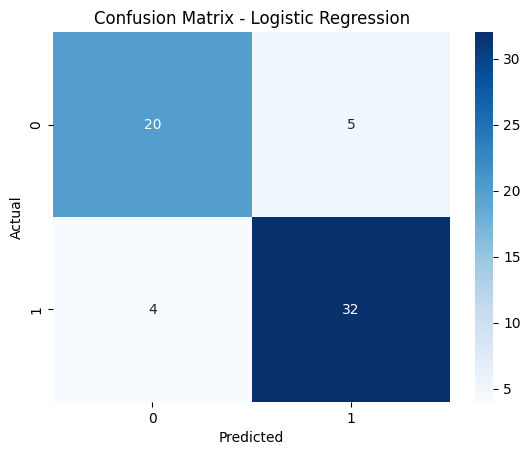

In [32]:
cm = confusion_matrix(Y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
print(classification_report(Y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.86      0.89      0.88        36

    accuracy                           0.85        61
   macro avg       0.85      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



Step 5 — Best Model Analysis

Among all the models tested, Logistic Regression achieved the best overall performance with an

Accuracy of 85.25%

Precision of 86.49%

Recall of 88.89%

F1 Score of 87.67%.

The confusion matrix showed that the model correctly classified 20 non-disease cases and 32 disease cases. It produced only 5 False Positives and 4 False Negatives.

**Since False Negatives are particularly critical in medical diagnosis because they represent missed disease cases, the model's high Recall and low False Negative count make it suitable for heart disease prediction.**

Therefore, Logistic Regression was selected as the final model.


Conclusion

1. The heart disease dataset was successfully cleaned and preprocessed by removing duplicate records and preparing the data for training.
2. Correlation analysis was used to identify the most relevant features and remove less useful attributes.
3. Five classification models were trained and evaluated using Accuracy, Precision, Recall, and F1 Score.
4. Logistic Regression achieved the best performance with an Accuracy of 85.25%, Recall of 88.89%, and F1 Score of 87.67%.
5. Based on the evaluation results and confusion matrix analysis, Logistic Regression was selected as the most suitable model for predicting heart disease in this dataset.
